# Datasets Exploration


Esplorazione dei dataset clinici per il progetto NEMESIS.
In questo notebook uniamo i log di data retrieval (`assets/dataset_summaries/data_summary__*.csv`) con i metadati clinici reali (`participants.tsv`)

In [1]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Path dinamici relativi alla posizione del progetto
project_root = '/Users/emmatosato/Local Projects/Local PhD Projects/NEMESIS_fs'
REPORTS_DIR = Path(project_root) / "assets" / "dataset_summaries"

# Caricamento dei file csv generati dalla pipeline di retrieval
CSV_FILES = sorted(REPORTS_DIR.glob("data_summary__*.csv"))
CSV_FILES

[PosixPath('/Users/emmatosato/Local Projects/Local PhD Projects/NEMESIS_fs/assets/dataset_summaries/data_summary__UCL-UK_UCLStrokeData.csv'),
 PosixPath('/Users/emmatosato/Local Projects/Local PhD Projects/NEMESIS_fs/assets/dataset_summaries/data_summary__UKLFR_stroke_UKLFR.csv'),
 PosixPath('/Users/emmatosato/Local Projects/Local PhD Projects/NEMESIS_fs/assets/dataset_summaries/data_summary__UNIPD_PASPORT.csv'),
 PosixPath('/Users/emmatosato/Local Projects/Local PhD Projects/NEMESIS_fs/assets/dataset_summaries/data_summary__UNIPD_PSP.csv'),
 PosixPath('/Users/emmatosato/Local Projects/Local PhD Projects/NEMESIS_fs/assets/dataset_summaries/data_summary__UNIPD_WashU.csv')]

In [5]:
# Carichiamo ogni CSV in un dizionario {nome_dataset: DataFrame}, usando come
# chiave il nome file senza prefisso/estensione (es. "UNIPD_WashU",
# "UCL-UK_UCLStrokeData") - stesso safe_name usato da scripts/data_summary.py
PREFIX = "data_summary__"
datasets_csv = {
    f.stem[len(PREFIX):]: pd.read_csv(f, dtype=str)
    for f in CSV_FILES
}
list(datasets_csv.keys())

['UCL-UK_UCLStrokeData',
 'UKLFR_stroke_UKLFR',
 'UNIPD_PASPORT',
 'UNIPD_PSP',
 'UNIPD_WashU']

## Report CSV (Data Retrieval Summaries)

#### Columns

In [54]:
# Raccogliamo e mostriamo tutte le colonne possibili in tutto il progetto
all_possible_columns = set()
for df in datasets_csv.values():
    for c in df.columns:
        if c != "subject":
            all_possible_columns.add(c)
            
print("Colonne disponibili nei CSV per l'analisi:")
for col in sorted(all_possible_columns):
    print(f" -> '{col}'")


Colonne disponibili nei CSV per l'analisi:
 -> 'feature/func/FC-pearson'
 -> 'feature/func/motion'
 -> 'feature/func/outliers'
 -> 'lesion/manual_masks/anat/lesion_mask'


### Soggetti Totali per Dataset (Conteggio Univoco)


Numero complessivo di soggetti trovati in ciascun summary CSV. Per evitare di sovrastimare il campione, viene estratto il numero univoco degli ID soggetto (`subject`), ignorando potenziali righe multiple.

In [55]:
# Contiamo solo gli ID univoci per colonna 'subject'
totals_unique = {name: df['subject'].nunique() for name, df in datasets_csv.items()}

for name, n in totals_unique.items():
    print(f"{name}: {n} soggetti univoci")
    
print(f"\nTotale globale: {sum(totals_unique.values())} soggetti univoci")

UCL-UK_UCLStrokeData: 4119 soggetti univoci
UKLFR_stroke_UKLFR: 697 soggetti univoci
UNIPD_PASPORT: 83 soggetti univoci
UNIPD_PSP: 168 soggetti univoci
UNIPD_WashU: 258 soggetti univoci

Totale globale: 5325 soggetti univoci


### Controllo Duplicati

Verifichiamo se nei log dei dataset sono presenti soggetti duplicati. Una riga duplicata in questa fase indica probabili errori a monte nella scrittura dei CSV o sovrapposizioni nelle query.

In [56]:
print("=== Controllo Duplicati ===")
duplicati_trovati = False

for name, df in datasets_csv.items():
    # Troviamo le righe dove la colonna 'subject' è duplicata
    is_duplicate = df.duplicated(subset=['subject'], keep=False)
    n_duplicati = is_duplicate.sum()
    
    if n_duplicati > 0:
        duplicati_trovati = True
        print(f"⚠️ ATTENZIONE: {name} ha {n_duplicati} righe duplicate!")
        # Mostriamo quali sono per facilitare il debug
        display(df[is_duplicate].sort_values(by='subject'))
    else:
        print(f"{name}: 0 duplicati.")

if not duplicati_trovati:
    print("\nNessun duplicato trovato. Possiamo procedere con i conteggi in sicurezza.")


=== Controllo Duplicati ===
UCL-UK_UCLStrokeData: 0 duplicati.
UKLFR_stroke_UKLFR: 0 duplicati.
UNIPD_PASPORT: 0 duplicati.
UNIPD_PSP: 0 duplicati.
UNIPD_WashU: 0 duplicati.

Nessun duplicato trovato. Possiamo procedere con i conteggi in sicurezza.


### Disponibilità Dati per tipologia di Modalità


Per ogni dataset, controlliamo quanti soggetti unici hanno effettivamente i dati richiesti (es. la maschera di lesione, `lesion_mask`).
Prima di eseguire il conteggio dei flag `"present"`, vengono rimosse preventivamente le eventuali righe duplicate, garantendo che ogni soggetto "valido" pesi esattamente `1` sul totale.

In [57]:
# Mappa di rinomina
COL_RENAMES = {
    "feature/func/FC-pearson": "FC (Pearson)",
    "lesion/manual_masks/anat/lesion_mask": "Lesion Mask"
}

report_rows = []

for name, df in datasets_csv.items():
    df_unique = df.drop_duplicates(subset=["subject"])
    
    # Escludiamo "subject", "motion" e "outliers"
    data_columns = [c for c in df_unique.columns 
                    if c != "subject" 
                    and "motion" not in c 
                    and "outliers" not in c]
                    
    n_subjects = df_unique['subject'].nunique()
    row = {"Dataset": name, "Total ID Subjects": n_subjects}
    
    for col in data_columns:
        n_present = (df_unique[col] == "present").sum()
        n_incomplete = (df_unique[col] == "incomplete").sum()
        
        # Traduciamo il nome della colonna in modo leggibile
        col_name = COL_RENAMES.get(col, col)
        
        row[col_name] = n_present
        row[f"{col_name} (Inc.)"] = n_incomplete
        
    report_rows.append(row)

# Creazione DataFrame
df_report = pd.DataFrame(report_rows)

# PULIZIA VISIVA: Rimuoviamo le colonne "(Inc.)" se sono tutte a 0
# Così la tabella non si allarga inutilmente finché i dati sono perfetti
colonne_da_rimuovere = [c for c in df_report.columns if "(Inc.)" in c and df_report[c].sum() == 0]
df_report = df_report.drop(columns=colonne_da_rimuovere)

display(df_report)


,Dataset,Total ID Subjects,FC (Pearson),Lesion Mask
0,UCL-UK_UCLStrokeData,4119,0,4119
1,UKLFR_stroke_UKLFR,697,0,697
2,UNIPD_PASPORT,83,0,83
3,UNIPD_PSP,168,0,168
4,UNIPD_WashU,258,225,202


### Confronto Mismatch

In questa cella possiamo verificare l'allineamento tra due flussi di dati specifici. Ad esempio, possiamo controllare quanti pazienti hanno la maschera di lesione strutturale (`COL_A`) ma non hanno i dati di connettività funzionale (`COL_B`), o viceversa.


In [58]:
# 1. Colonne da confrontare
COL_A = "lesion/manual_masks/anat/lesion_mask"
COL_B = "feature/func/FC-pearson"

# 2. Opzioni di filtraggio e stampa
STAMPA_DETTAGLIO_SOGGETTI = False  # Metti a True se vuoi vedere i DataFrame riga per riga
DATASET_DA_CONTROLLARE = ["UNIPD_WashU"]  # Lascia la lista vuota [] per testarli tutti

# 3. Dizionario di rinomina
COL_RENAMES = {
    COL_A: "Lesion Mask",
    COL_B: "FC (Pearson)",
    "feature/func/motion": "fMRI Motion",
    "feature/func/outliers": "fMRI Outliers"
}


In [59]:
nome_a = COL_RENAMES.get(COL_A, COL_A)
nome_b = COL_RENAMES.get(COL_B, COL_B)

print(f"🔍 Eseguo confronto Mismatch: [{nome_a}] vs [{nome_b}]\n")

for name, df in datasets_csv.items():
    df_unique = df.drop_duplicates(subset=["subject"])
    n_tot = len(df_unique)
    
    if COL_A not in df_unique.columns or COL_B not in df_unique.columns:
        print(f"=== {name} ===")
        print(f"  ⚠️ Saltato: Almeno una delle due colonne manca.\n")
        continue
        
    is_mismatch = df_unique[COL_A] != df_unique[COL_B]
    n_mismatch = is_mismatch.sum()
    
    print(f"=== {name} ===")
    print(f"  ✅ Coincidenti: {n_tot - n_mismatch} / {n_tot}")
    print(f"  ❌ Mismatch:    {n_mismatch} / {n_tot}")
    
    if n_mismatch > 0:
        # Applichiamo la rinomina anche alla tabella stampata per pulizia!
        df_mismatch = df_unique.loc[is_mismatch, ["subject", COL_A, COL_B]].rename(columns=COL_RENAMES)
        display(df_mismatch)
    print()


🔍 Eseguo confronto Mismatch: [Lesion Mask] vs [FC (Pearson)]

=== UCL-UK_UCLStrokeData ===
  ✅ Coincidenti: 0 / 4119
  ❌ Mismatch:    4119 / 4119


,subject,Lesion Mask,FC (Pearson)
0,sub-STUCLUK0001,present,missing
1,sub-STUCLUK0002,present,missing
2,sub-STUCLUK0003,present,missing
3,sub-STUCLUK0004,present,missing
4,sub-STUCLUK0005,present,missing
...,...,...,...
4114,sub-STUCLUK4115,present,missing
4115,sub-STUCLUK4116,present,missing
4116,sub-STUCLUK4117,present,missing
4117,sub-STUCLUK4118,present,missing



=== UKLFR_stroke_UKLFR ===
  ✅ Coincidenti: 0 / 697
  ❌ Mismatch:    697 / 697


,subject,Lesion Mask,FC (Pearson)
0,sub-STUKLFR0001,present,missing
1,sub-STUKLFR0002,present,missing
2,sub-STUKLFR0003,present,missing
3,sub-STUKLFR0004,present,missing
4,sub-STUKLFR0006,present,missing
...,...,...,...
692,sub-STUKLFR0730,present,missing
693,sub-STUKLFR0731,present,missing
694,sub-STUKLFR0732,present,missing
695,sub-STUKLFR0733,present,missing



=== UNIPD_PASPORT ===
  ✅ Coincidenti: 0 / 83
  ❌ Mismatch:    83 / 83


,subject,Lesion Mask,FC (Pearson)
0,sub-STUNIPD0489,present,missing
1,sub-STUNIPD0490,present,missing
2,sub-STUNIPD0491,present,missing
3,sub-STUNIPD0492,present,missing
4,sub-STUNIPD0493,present,missing
...,...,...,...
78,sub-STUNIPD0578,present,missing
79,sub-STUNIPD0580,present,missing
80,sub-STUNIPD0583,present,missing
81,sub-STUNIPD0584,present,missing



=== UNIPD_PSP ===
  ✅ Coincidenti: 0 / 168
  ❌ Mismatch:    168 / 168


,subject,Lesion Mask,FC (Pearson)
0,sub-STUNIPD0252,present,missing
1,sub-STUNIPD0253,present,missing
2,sub-STUNIPD0254,present,missing
3,sub-STUNIPD0255,present,missing
4,sub-STUNIPD0256,present,missing
...,...,...,...
163,sub-STUNIPD0477,present,missing
164,sub-STUNIPD0483,present,missing
165,sub-STUNIPD0485,present,missing
166,sub-STUNIPD0486,present,missing



=== UNIPD_WashU ===
  ✅ Coincidenti: 169 / 258
  ❌ Mismatch:    89 / 258


,subject,Lesion Mask,FC (Pearson)
0,sub-STUNIPD0001,present,missing
16,sub-STUNIPD0021,present,missing
20,sub-STUNIPD0026,present,missing
31,sub-STUNIPD0043,present,missing
50,sub-STUNIPD0064,present,missing
...,...,...,...
253,sub-STUNIPDHC0063,missing,present
254,sub-STUNIPDHC0064,missing,present
255,sub-STUNIPDHC0065,missing,present
256,sub-STUNIPDHC0066,missing,present


#### WashU

In [60]:
# Impostazioni per l'esplorazione puntuale
ESPLORA_PUNTUALE = True
DATASET_PUNTUALE = "UNIPD_WashU"

if ESPLORA_PUNTUALE and DATASET_PUNTUALE in datasets_csv:
    print(f"Eseguo confronto Mismatch Puntuale per: {DATASET_PUNTUALE}\n")
    
    df = datasets_csv[DATASET_PUNTUALE]
    df_unique = df.drop_duplicates(subset=["subject"])
    n_tot = len(df_unique)
    
    if COL_A in df_unique.columns and COL_B in df_unique.columns:
        is_mismatch = df_unique[COL_A] != df_unique[COL_B]
        n_mismatch = is_mismatch.sum()
        
        print(f"Totale Mismatch: {n_mismatch} / {n_tot}\n")
        
        if n_mismatch > 0:
            print("Spaccato dei casi (Crosstab):")
            crosstab = pd.crosstab(df_unique[COL_A], df_unique[COL_B], 
                                   rownames=[nome_a], colnames=[nome_b])
            display(crosstab)
            
            # Tipologia 1
            mask_a_only = (df_unique[COL_A] == "present") & (df_unique[COL_B] == "missing")
            if mask_a_only.sum() > 0:
                print(f"\n-> Hanno [{nome_a}] ma MANCA [{nome_b}] ({mask_a_only.sum()} soggetti):")
                df_show_a = df_unique.loc[mask_a_only, ["subject", COL_A, COL_B]].rename(columns=COL_RENAMES)
                display(df_show_a)
                
            # Tipologia 2
            mask_b_only = (df_unique[COL_A] == "missing") & (df_unique[COL_B] == "present")
            if mask_b_only.sum() > 0:
                print(f"\n-> Hanno [{nome_b}] ma MANCA [{nome_a}] ({mask_b_only.sum()} soggetti):")
                df_show_b = df_unique.loc[mask_b_only, ["subject", COL_A, COL_B]].rename(columns=COL_RENAMES)
                display(df_show_b)
    else:
        print("Le colonne selezionate non sono disponibili in questo dataset.")


Eseguo confronto Mismatch Puntuale per: UNIPD_WashU

Totale Mismatch: 89 / 258

Spaccato dei casi (Crosstab):


FC (Pearson),missing,present
Lesion Mask,,
missing,0,56
present,33,169



-> Hanno [Lesion Mask] ma MANCA [FC (Pearson)] (33 soggetti):


,subject,Lesion Mask,FC (Pearson)
0,sub-STUNIPD0001,present,missing
16,sub-STUNIPD0021,present,missing
20,sub-STUNIPD0026,present,missing
31,sub-STUNIPD0043,present,missing
50,sub-STUNIPD0064,present,missing
68,sub-STUNIPD0086,present,missing
69,sub-STUNIPD0087,present,missing
71,sub-STUNIPD0090,present,missing
74,sub-STUNIPD0093,present,missing
81,sub-STUNIPD0101,present,missing



-> Hanno [FC (Pearson)] ma MANCA [Lesion Mask] (56 soggetti):


,subject,Lesion Mask,FC (Pearson)
202,sub-STUNIPDHC0001,missing,present
203,sub-STUNIPDHC0002,missing,present
204,sub-STUNIPDHC0003,missing,present
205,sub-STUNIPDHC0004,missing,present
206,sub-STUNIPDHC0006,missing,present
207,sub-STUNIPDHC0007,missing,present
208,sub-STUNIPDHC0008,missing,present
209,sub-STUNIPDHC0009,missing,present
210,sub-STUNIPDHC0010,missing,present
211,sub-STUNIPDHC0011,missing,present


## Merging csv-tsv

La generazione dei TSV filtrati (`assets/metadata/`) non avviene più qui: vive in `scripts/build_participant_metadata.py` (config: `config/pipelines/build_participant_metadata.json`), rieseguibile da riga di comando senza aprire il notebook — vedi `docs/dev/metadata.md`. Questa sezione carica solo l'output già scritto su disco, per il report sottostante:
- `_participants_lesions.tsv`: solo chi ha una maschera di lesione validata.
- `_participants_features.tsv`: solo chi ha i dati fMRI validati completi (escludendo eventuali `incomplete`).
- `_participants_join.tsv`: l'intersezione pura, chi ha **sia** la lesione **sia** i dati funzionali.

In [ ]:
# METADATA_OUT_DIR resta definita qui perché usata dalle celle di report sottostanti
# (che leggono i TSV già scritti da scripts/build_participant_metadata.py).
METADATA_OUT_DIR = Path(project_root) / "assets" / "metadata"

## Report tsv (Metadata)

Analisi esplorativa dei dataset incrociati. Prima eseguiamo un **EDA di Base** (statistiche descrittive, controllo missing values e duplicati), per poi passare a un'esplorazione visiva avanzata (Demografiche, Volume Lesionale, Test Clinici).


### Setup e Caricamento

Modifica le variabili `DATASETS` e `TARGET_TSV` qui sotto per cambiare il set di dati esplorato dall'intero blocco di analisi.


In [62]:
DATASETS = ["UNIPD_WashU"] # Puoi aggiungere "UKLFR_stroke_UKLFR", ecc.
TARGET_TSV = "participants_features.tsv" # Opzioni: _lesions.tsv, _features.tsv, _join.tsv

df_list = []
for name in DATASETS:
    path = METADATA_OUT_DIR / f"{name}_{TARGET_TSV}"
    if path.exists():
        df_list.append(pd.read_csv(path, sep='\t'))

active_df = pd.concat(df_list, ignore_index=True) if df_list else pd.DataFrame()
print(f"Dataset caricato in 'active_df': {len(active_df)} soggetti trovati.")


Dataset caricato in 'active_df': 225 soggetti trovati.


### Columns

In [63]:
active_df.columns

Index(['participant_id', 'center_id', 'disease_id', 'disease_notes', 'dataset',
       'age', 'sex', 'handedness', 'education', 'lesion_side', 'clinical_date',
       'NIHSS', 'NIHSS_1A', 'NIHSS_1B', 'NIHSS_1C', 'NIHSS_2', 'NIHSS_3',
       'NIHSS_4', 'NIHSS_5A', 'NIHSS_5B', 'NIHSS_6A', 'NIHSS_6B', 'NIHSS_7',
       'NIHSS_8', 'NIHSS_9', 'NIHSS_10', 'NIHSS_11', 'GDS_15',
       'behavioral_date', 'acq_time', 'Corsi', 'ARAT_L', 'ARAT_R', '9HPT_L',
       '9HPT_R', 'Boston_nam', 'Clock', 'participant_id_dmp', 'subject',
       'feature/func/FC-pearson', 'feature/func/motion',
       'feature/func/outliers', 'lesion/manual_masks/anat/lesion_mask'],
      dtype='str')

### Integrità del Dato (Missing Values e Duplicati)


Verifichiamo la qualità del sotto-dataset selezionato (`active_df`).
Un controllo essenziale prima di qualsiasi analisi statistica è accertarsi che non vi siano ID duplicati per errore e quantificare esattamente quante informazioni anagrafiche o cliniche

Duplicati ID totali: 0



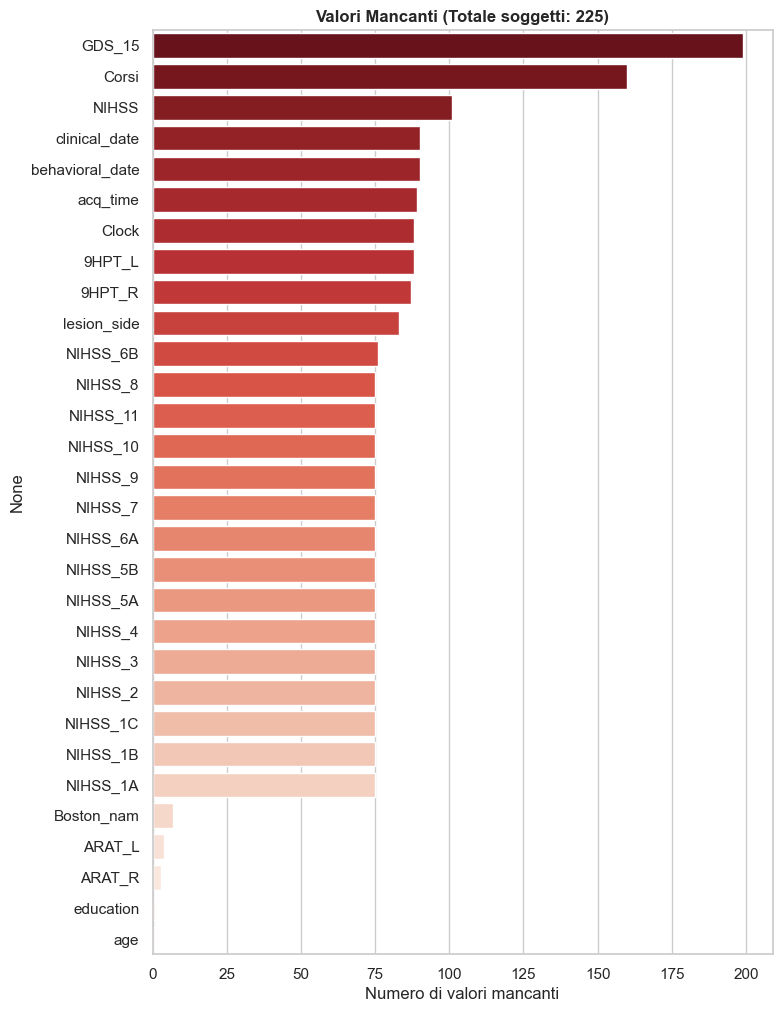

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

print(f"Duplicati ID totali: {active_df.duplicated(subset=['participant_id']).sum()}\n")

missing = active_df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if missing.empty:
    print("Nessun valore mancante nel dataset!")
else:
    # Plot grafico dei missing values
    plt.figure(figsize=(8, len(missing)*0.4))
    sns.barplot(x=missing.values, y=missing.index, hue=missing.index, legend=False, palette="Reds_r")
    plt.title(f"Valori Mancanti (Totale soggetti: {len(active_df)})", fontweight='bold')
    plt.xlabel("Numero di valori mancanti")
    plt.show()


### Conteggio Iniziale Sani vs Malati

In [65]:
print("=== CONTEGGIO GRUPPI (Sani vs Malati) ===")
if 'disease_id' in active_df.columns:
    print(active_df['disease_id'].value_counts().to_string())
else:
    print("Colonna 'disease_id' mancante.")
print("\n")

=== CONTEGGIO GRUPPI (Sani vs Malati) ===
disease_id
ST    169
HC     56




### Analisi Demografica


Esplorazione visiva e tabellare delle variabili demografiche di base del campione. 
I grafici mostrano la distribuzione dell'età e del sesso (eventualmente stratificati per dataset se ne è stato caricato più di uno). La tabella sottostante riassume i descrittori statistici chiave (media, varianza, percentili) per età, educazione e dominanza manuale.


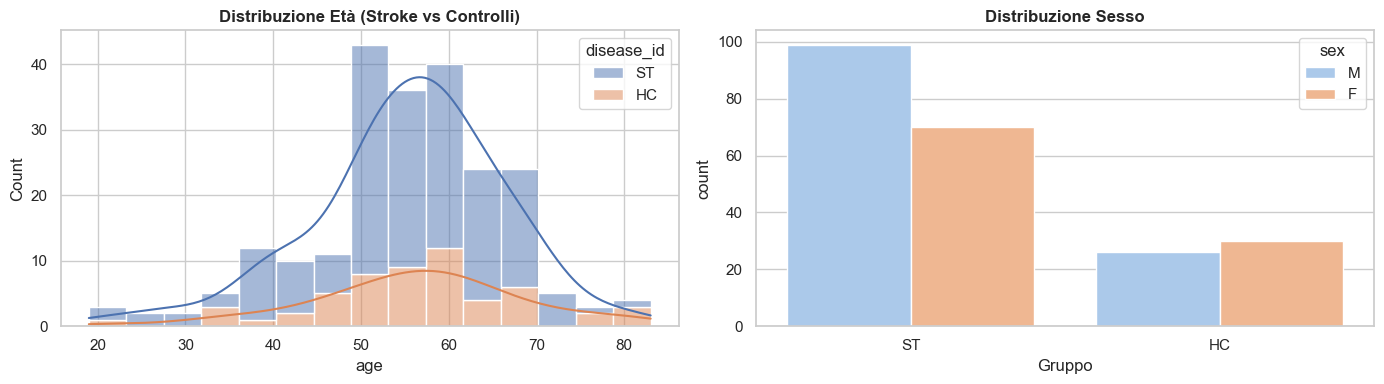

,age,sex,education,handedness,disease_id
count,224.0,225,224.0,225,225
unique,NaN,2,NaN,2,2
top,NaN,M,NaN,right,ST
freq,NaN,125,NaN,202,169
mean,55.3,NaN,13.5,NaN,NaN
std,11.0,NaN,2.5,NaN,NaN
min,19.0,NaN,7.0,NaN,NaN
25%,50.0,NaN,12.0,NaN,NaN
50%,57.0,NaN,13.0,NaN,NaN
75%,62.0,NaN,15.0,NaN,NaN


In [66]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Usiamo 'disease_id' (ST/HC) per stratificare se esiste, altrimenti 'dataset'
hue_col = 'disease_id' if 'disease_id' in active_df.columns else 'dataset'

# Plot Età
if 'age' in active_df.columns:
    sns.histplot(data=active_df, x='age', hue=hue_col, multiple="stack", bins=15, kde=True, ax=axes[0])
    axes[0].set_title("Distribuzione Età (Stroke vs Controlli)", fontweight='bold')

# Plot Sesso (X=Gruppo, Colore=Sesso)
if 'sex' in active_df.columns:
    sns.countplot(data=active_df, x=hue_col, hue='sex', palette="pastel", ax=axes[1])
    axes[1].set_title("Distribuzione Sesso", fontweight='bold')
    axes[1].set_xlabel("Gruppo")

plt.tight_layout()
plt.show()

# Tabella Descrittiva Demografica
cols_demo = [c for c in ['age', 'sex', 'education', 'handedness', 'disease_id'] if c in active_df.columns]
display(active_df[cols_demo].describe(include='all').round(1))


### Lateralità della Lesione

Analisi della distribuzione degli ictus negli emisferi cerebrali (Destro vs Sinistro) divisa per dataset. Valutare eventuali sbilanciamenti è fondamentale: un eccesso di lesioni sinistre tenderà a produrre un campione con maggiori deficit di linguaggio (afasia), mentre lesioni destre impatteranno maggiormente su attenzione e abilità visuo-spaziali (es. neglect).

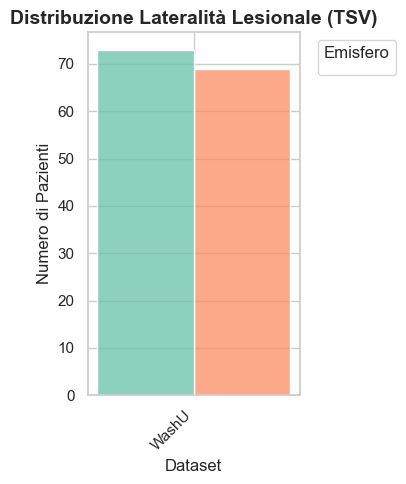

In [67]:
if 'lesion_side' in active_df.columns:
    # Usiamo una larghezza dinamica in base a quanti dataset ci sono, ma massimo 8
    n_datasets = active_df['dataset'].nunique()
    fig_width = min(8, max(4, n_datasets * 2))
    plt.figure(figsize=(fig_width, 5))
    
    # Rimuoviamo chi non ha una lesione
    df_plot = active_df.dropna(subset=['lesion_side'])
    
    if not df_plot.empty:
        # Usa histplot invece di countplot: shrink=0.5 snellisce le colonne!
        sns.histplot(data=df_plot, x='dataset', hue='lesion_side', multiple='dodge', shrink=0.5, palette='Set2')
        
        plt.title('Distribuzione Lateralità Lesionale (TSV)', fontsize=14, fontweight='bold')
        plt.xlabel('Dataset')
        plt.ylabel('Numero di Pazienti')
        plt.xticks(rotation=45, ha='right')
        plt.legend(title='Emisfero', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()
    else:
        print("I dati di lateralità ('lesion_side') sono tutti vuoti in questo subset.")
else:
    print("La colonna 'lesion_side' non è presente nel dataset.")


### Test Clinici e Comportamentali

Panoramica sui punteggi dei principali test clinici (Gravità dello Stroke, Motricità fine, Linguaggio, Memoria e Funzioni Esecutive).
Tramite `FacetGrid` vengono generati istogrammi multipli per ogni test disponibile nel dataset. Questo ci permette di capire immediatamente se il campione è fortemente sbilanciato (es. tutti pazienti afasici o tutti pazienti con motricità intatta) o se presenta una distribuzione normale delle disabilità. Vengono ignorati automaticamente i valori mancanti (`NaN`).

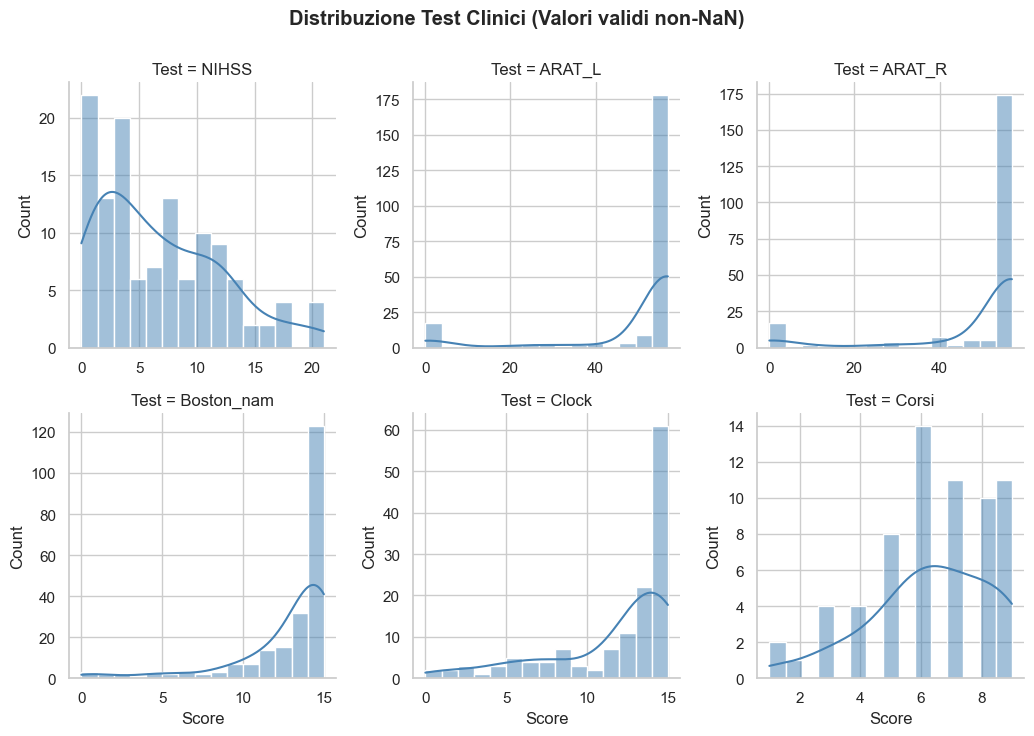

In [68]:
# 5. TEST CLINICI COMPORTAMENTALI
clinical_cols = ['NIHSS', 'ARAT_L', 'ARAT_R', 'Boston_nam', 'Clock', 'Corsi']
avail_cols = [c for c in clinical_cols if c in active_df.columns]

if avail_cols:
    melted = active_df.melt(id_vars=['participant_id', 'dataset'], 
                            value_vars=avail_cols, 
                            var_name='Test', value_name='Score').dropna()
    
    if not melted.empty:
        g = sns.FacetGrid(melted, col="Test", col_wrap=3, height=3.5, sharex=False, sharey=False)
        g.map_dataframe(sns.histplot, x="Score", bins=15, kde=True, color="steelblue")
        g.fig.suptitle("Distribuzione Test Clinici (Valori validi non-NaN)", y=1.05, fontweight='bold')
        plt.show()
    else:
        print("Tutti i test clinici sono vuoti (NaN) per questi soggetti.")
else:
    print("Nessuna colonna clinica standard trovata nel dataset.")


### Gravità Clinica (NIHSS)

Focus specifico sulla gravità dell'ictus al momento dell'ammissione, misurata tramite il *National Institutes of Health Stroke Scale* (NIHSS). I controlli sani vengono automaticamente esclusi da questo plot.


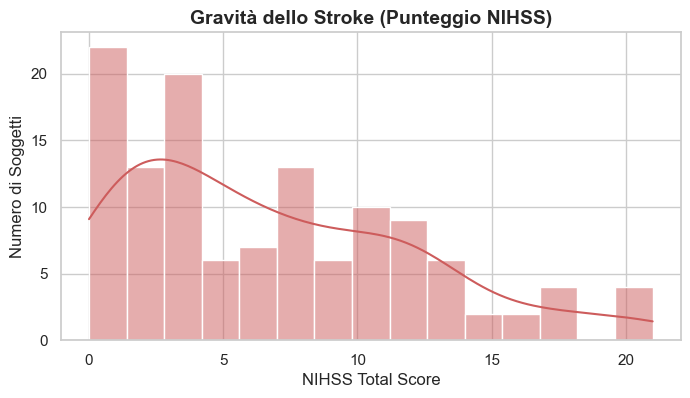

In [69]:
if 'NIHSS' in active_df.columns:
    plt.figure(figsize=(8, 4))
    
    # Assicuriamoci di isolare solo i pazienti (ST) se nel dataset ci sono anche controlli sani
    if 'disease_id' in active_df.columns:
        df_plot = active_df[active_df['disease_id'] == 'ST']
    else:
        df_plot = active_df
        
    sns.histplot(data=df_plot, x='NIHSS', bins=15, color='indianred', kde=True)
    
    plt.title("Gravità dello Stroke (Punteggio NIHSS)", fontsize=14, fontweight='bold')
    plt.xlabel("NIHSS Total Score")
    plt.ylabel("Numero di Soggetti")
    plt.show()
else:
    print("Dati NIHSS non disponibili in questo subset.")


### Matrice di Correlazione Clinica (Heatmap)

Esplorazione visiva delle correlazioni lineari (Pearson) tra le variabili cliniche e demografiche continue. Questo strumento permette di identificare rapidamente collinearità e pattern latenti (es. come l'età o l'educazione influenzano le performance nei test comportamentali, o se c'è un'alta concordanza tra i vari indici motori).
crea una fantastica mappa di calore.

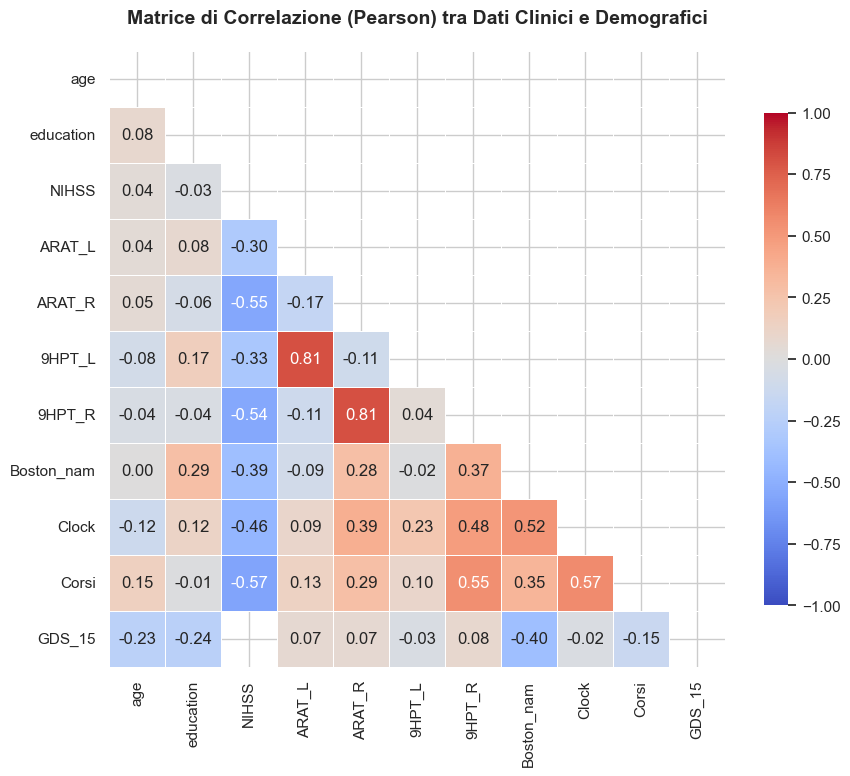

In [70]:
import numpy as np

# Selezioniamo solo le colonne numeriche di interesse (Escludiamo ID e roba tecnica)
cols_to_correlate = ['age', 'education', 'NIHSS', 'ARAT_L', 'ARAT_R', '9HPT_L', '9HPT_R', 'Boston_nam', 'Clock', 'Corsi', 'GDS_15']

# Teniamo solo le colonne effettivamente presenti in active_df
valid_cols = [c for c in cols_to_correlate if c in active_df.columns]

if len(valid_cols) > 1:
    # Calcoliamo la matrice di correlazione di Pearson
    corr_matrix = active_df[valid_cols].corr(method='pearson')
    
    # Creiamo una maschera per nascondere la metà superiore (che è un duplicato speculare)
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
                vmin=-1, vmax=1, center=0, square=True, linewidths=.5, cbar_kws={"shrink": .8})
    
    plt.title("Matrice di Correlazione (Pearson) tra Dati Clinici e Demografici", fontsize=14, fontweight='bold', pad=20)
    plt.show()
else:
    print("Non ci sono abbastanza variabili cliniche numeriche per calcolare una matrice di correlazione.")
